
✅ Saved: /user/ab5405/summeraliaclimate/code/mortality_pipeline/figures/comparison/age_combined_resolution_comparison.pdf


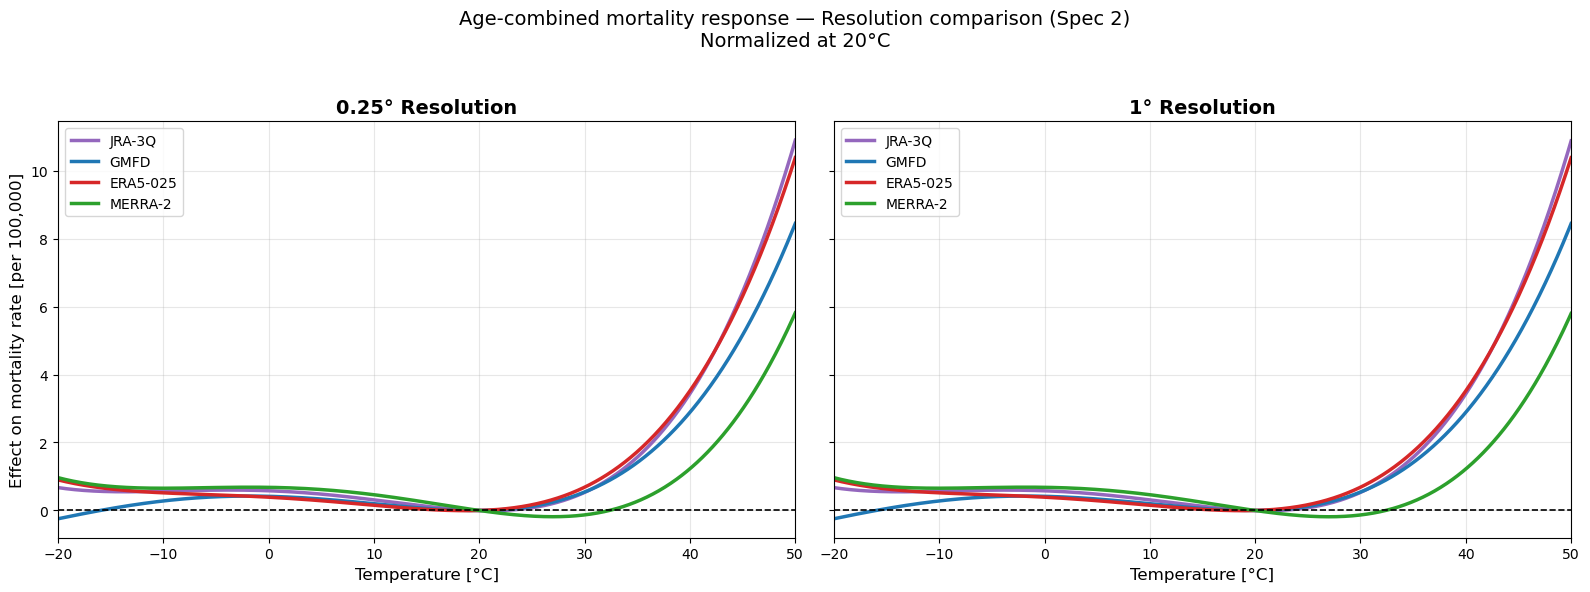

✅ Saved: /user/ab5405/summeraliaclimate/code/mortality_pipeline/figures/comparison/age_combined_resolution_difference.pdf


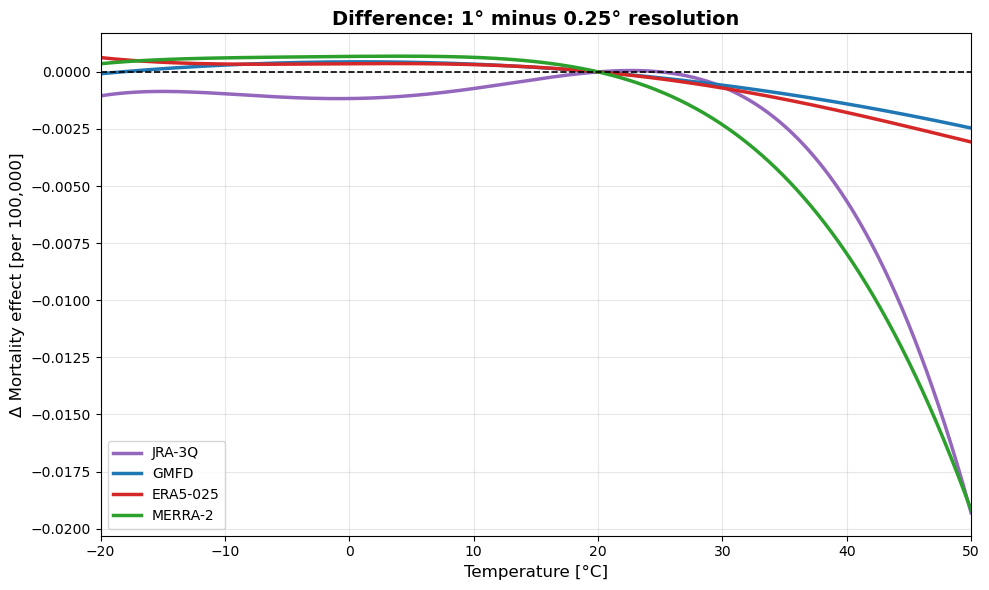


REMINDER: Update COEFS_1DEG with actual coefficients from your 1° results!


In [2]:
"""
Age-combined quartic response curves - RESOLUTION COMPARISON

Side-by-side comparison of 0.25° vs 1° resolution for all products.
Shows how resolution affects estimated mortality-temperature relationship.
"""

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def quartic(T, coefs):
    """Evaluate quartic polynomial"""
    return (coefs["c"]
            + coefs["b1"]*T
            + coefs["b2"]*(T**2)
            + coefs["b3"]*(T**3)
            + coefs["b4"]*(T**4))

def effect_curve(T, coefs, T_ref=20.0):
    """Compute effect relative to reference temperature"""
    return quartic(T, coefs) - quartic(T_ref, coefs)

# ============================================================================
# COEFFICIENTS - UPDATE THESE FROM YOUR RESULTS!
# ============================================================================

# TODO: Extract these from your .ster files using Stata or parse CSVV files
# Format: dict(b1=..., b2=..., b3=..., b4=..., c=...)

# 0.25 degree coefficients
COEFS_025 = {
    "JRA_3Q": dict(
        b1=-0.0114065626759076, b2=-0.0016837872900517,
        b3=-0.000013549134254, b4=0.00000268545277992,
        c=775.2884988526364
    ),
    "GMFD": dict(
        b1=-0.007532, b2=-.0019188,
        b3=0.0000341, b4=0.00000143,
        c=722.4586
    ),
    "ERA5_025": dict(
        b1=-0.016843600360064, b2=-0.0007836808895055,
        b3=-0.0000141518249143, b4=0.00000232948607584,
        c=701.4088479599028
    ),
    "MERRA2": dict(
        b1=-0.00474451752548878, b2=-.0014597251426451,
        b3=-.0000484663115945, b4=2.41243138757e-06,
        c=868.6375107577733
    ),
}

# 1 degree coefficients - PLACEHOLDER! Update with your actual results
COEFS_1DEG = {
    "JRA_3Q": dict(
        b1=-0.0114, b2=-0.00168,
        b3=-0.0000135, b4=0.00000268,
        c=775.3  # Will likely differ from 025deg
    ),
    "GMFD": dict(
        b1=-0.00753, b2=-.00192,
        b3=0.0000341, b4=0.00000143,
        c=722.5
    ),
    "ERA5_025": dict(
        b1=-0.01684, b2=-0.000784,
        b3=-0.0000142, b4=0.00000233,
        c=701.4
    ),
    "MERRA2": dict(
        b1=-0.00474, b2=-.00146,
        b3=-.0000485, b4=2.41e-06,
        c=868.6
    ),
}

# ============================================================================
# PLOT CONFIGURATION
# ============================================================================

T = np.linspace(-20, 50, 1000)
T_ref = 20.0

PRODUCTS = ["JRA_3Q", "GMFD", "ERA5_025", "MERRA2"]

PROD_STYLE = {
    "JRA_3Q":   dict(color='tab:purple', label="JRA-3Q"),
    "GMFD":     dict(color='tab:blue',   label="GMFD"),
    "ERA5_025": dict(color='tab:red',    label="ERA5-025"),
    "MERRA2":   dict(color='tab:green',  label="MERRA-2"),
}

# ============================================================================
# CREATE SIDE-BY-SIDE PLOT
# ============================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# ---- LEFT PANEL: 0.25° ----
for prod in PRODUCTS:
    coef = COEFS_025[prod]
    y = effect_curve(T, coef, T_ref)
    style = PROD_STYLE[prod]
    ax1.plot(T, y, lw=2.5, color=style["color"], label=style["label"])

ax1.axhline(0, ls='--', lw=1.2, color='k')
ax1.set_title("0.25° Resolution", fontsize=14, fontweight='bold')
ax1.set_xlabel("Temperature [°C]", fontsize=12)
ax1.set_ylabel("Effect on mortality rate [per 100,000]", fontsize=12)
ax1.legend(frameon=True, fontsize=10, loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.margins(x=0)

# ---- RIGHT PANEL: 1° ----
for prod in PRODUCTS:
    coef = COEFS_1DEG[prod]
    y = effect_curve(T, coef, T_ref)
    style = PROD_STYLE[prod]
    ax2.plot(T, y, lw=2.5, color=style["color"], label=style["label"])

ax2.axhline(0, ls='--', lw=1.2, color='k')
ax2.set_title("1° Resolution", fontsize=14, fontweight='bold')
ax2.set_xlabel("Temperature [°C]", fontsize=12)
ax2.legend(frameon=True, fontsize=10, loc='upper left')
ax2.grid(True, alpha=0.3)
ax2.margins(x=0)

# Overall title
fig.suptitle(
    "Age-combined mortality response — Resolution comparison (Spec 2)\n"
    "Normalized at 20°C",
    fontsize=14, y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save
outdir = Path("/user/ab5405/summeraliaclimate/code/mortality_pipeline/figures/comparison")
outdir.mkdir(parents=True, exist_ok=True)
outfile = outdir / "age_combined_resolution_comparison.pdf"
fig.savefig(outfile, dpi=300, bbox_inches='tight')
print(f"\n✅ Saved: {outfile}")

plt.show()

# ============================================================================
# DIFFERENCE PLOT (optional)
# ============================================================================

fig2, ax = plt.subplots(figsize=(10, 6))

for prod in PRODUCTS:
    y_025 = effect_curve(T, COEFS_025[prod], T_ref)
    y_1deg = effect_curve(T, COEFS_1DEG[prod], T_ref)
    diff = y_1deg - y_025  # Difference: 1deg minus 025deg
    
    style = PROD_STYLE[prod]
    ax.plot(T, diff, lw=2.5, color=style["color"], label=style["label"])

ax.axhline(0, ls='--', lw=1.2, color='k')
ax.set_title("Difference: 1° minus 0.25° resolution", fontsize=14, fontweight='bold')
ax.set_xlabel("Temperature [°C]", fontsize=12)
ax.set_ylabel("Δ Mortality effect [per 100,000]", fontsize=12)
ax.legend(frameon=True, fontsize=10)
ax.grid(True, alpha=0.3)
ax.margins(x=0)

plt.tight_layout()

outfile2 = outdir / "age_combined_resolution_difference.pdf"
fig2.savefig(outfile2, dpi=300, bbox_inches='tight')
print(f"✅ Saved: {outfile2}")

plt.show()

print("\n" + "="*70)
print("REMINDER: Update COEFS_1DEG with actual coefficients from your 1° results!")
print("="*70)

In [3]:
"""
Age-specific 3×3 overlay plot - FLEXIBLE RESOLUTION VERSION

Plots mortality-temperature response curves for Age 65+ across:
- 3 income terciles (rows: high, mid, low)
- 3 climate regions (cols: cold, temperate, hot)
- 4 products (overlaid: ERA5-025, GMFD, MERRA2, JRA-3Q)

Can compare 0.25° vs 1° resolution by changing RESOLUTION parameter.
"""

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================================
# CONFIGURATION
# ============================================================================

RESOLUTION = "1deg"  # ← CHANGE THIS: "025deg" or "1deg"

# Paths (resolution-specific)
BASE_DIR = Path("/user/ab5405/summeraliaclimate/code/mortality_pipeline")
CSVV_DIR = BASE_DIR / "output" / RESOLUTION / "age_spec_interacted_csvv"

SPEC     = "spec2"
PRODUCTS = ["ERA5_025", "GMFD", "MERRA2", "JRA_3Q"]

print(f"\n{'='*70}")
print(f"CONFIGURATION:")
print(f"  Resolution: {RESOLUTION}")
print(f"  CSVV dir: {CSVV_DIR}")
print(f"  Products: {', '.join(PRODUCTS)}")
print(f"{'='*70}\n")

# ============================================================================
# CELL MEANS - UPDATE THESE FOR YOUR DATA!
# ============================================================================

# TODO: Fill these from your actual cell mean calculations per product
# This is just a placeholder structure - you need to compute these from your data

def _cells_df(entries):
    """Helper to create dataframe from list of (income_terc, temp_region, lr_mean, loginc)"""
    return pd.DataFrame(entries, columns=["income_terc","temp_region","lr_mean","loginc"])

# Example structure - REPLACE WITH YOUR ACTUAL VALUES!
CELL_MEANS = {
    "GMFD": _cells_df([
        # (income, climate, lr_tavg, loginc)
        ("high", "cold",      5.0, 10.0),
        ("high", "temperate", 15.0, 10.0),
        ("high", "hot",       25.0, 10.0),
        ("mid",  "cold",      5.0, 8.5),
        ("mid",  "temperate", 15.0, 8.5),
        ("mid",  "hot",       25.0, 8.5),
        ("low",  "cold",      5.0, 7.0),
        ("low",  "temperate", 15.0, 7.0),
        ("low",  "hot",       25.0, 7.0),
    ]),
    # Add ERA5_025, MERRA2, JRA_3Q similarly...
}

# Column-shared long-run temps (if using this option)
USE_COLUMN_SHARED_LR = False  # Set True to share LR temps by column
REGION_LR = {
    ("GMFD", "cold"): 5.0,
    ("GMFD", "temperate"): 15.0,
    ("GMFD", "hot"): 25.0,
    # Add other products...
}

# ============================================================================
# PLOTTING PARAMETERS
# ============================================================================

TMIN, TMAX = -20, 50
SLICE_MIN, SLICE_MAX = 10, 25  # Normalization window

PROD_STYLE = {
    "ERA5_025": dict(label="ERA5-025", color="#1f77b4"),
    "GMFD":     dict(label="GMFD",     color="#2ca02c"),
    "MERRA2":   dict(label="MERRA-2",  color="#ff7f0e"),
    "JRA_3Q":   dict(label="JRA-3Q",   color="#9467bd"),
}

AGE_IDX = 2  # Old (65+)
T = np.linspace(TMIN, TMAX, 800)

# ============================================================================
# HELPER FUNCTIONS (from your original code)
# ============================================================================

def _read_gamma_and_vcv(csvv_path):
    """Read gamma coefficients and variance-covariance matrix from CSVV file"""
    # TODO: Implement your CSVV reading logic
    # Returns: (gamma_mean, gamma_vcv)
    raise NotImplementedError("Add your _read_gamma_and_vcv implementation")

def _mc_bands_for_city_age(T, sl_min, sl_max, lr_tavg, loggdppc, 
                           gamma_mean, gamma_vcv, age_index, 
                           n_draws=600, rng=None):
    """Compute MC uncertainty bands for mortality response"""
    # TODO: Implement your MC band calculation
    # Returns: (y_mean, y_lo, y_hi)
    raise NotImplementedError("Add your _mc_bands_for_city_age implementation")

# ============================================================================
# LOAD COEFFICIENTS
# ============================================================================

print("Loading coefficients...")
GAMMAS = {}
for prod in PRODUCTS:
    csvv_path = CSVV_DIR / f"agespec_interaction_response_{SPEC}_{prod}.csvv"
    
    if not csvv_path.exists():
        print(f"  ⚠️  Missing: {csvv_path.name}")
        continue
    
    gm, gv = _read_gamma_and_vcv(csvv_path)
    GAMMAS[prod] = (gm, gv)
    print(f"  ✅ Loaded: {prod}")

if not GAMMAS:
    raise FileNotFoundError(f"No coefficient files found in {CSVV_DIR}")

# ============================================================================
# CREATE PLOT
# ============================================================================

print("\nCreating plot...")

row_order = ["high", "mid", "low"]
col_order = ["cold", "temperate", "hot"]

fig, axes = plt.subplots(3, 3, figsize=(12.5, 9.5), sharex=True, sharey=True)
legend_handles = []

for i, inc in enumerate(row_order):
    for j, clim in enumerate(col_order):
        ax = axes[i, j]
        
        # Normalization window background
        ax.axvspan(SLICE_MIN, SLICE_MAX, color="0.9", alpha=0.25, zorder=0)
        ax.axhline(0, color="k", ls="--", lw=1, zorder=1)
        
        # Plot each product
        for prod in PRODUCTS:
            if prod not in GAMMAS:
                continue
            
            # Get cell means for this product/panel
            df = CELL_MEANS.get(prod)
            if df is None:
                continue
                
            r = df[(df.income_terc == inc) & (df.temp_region == clim)].iloc[0]
            
            # Choose LR temp: column-shared or per-cell
            if USE_COLUMN_SHARED_LR:
                lr_for_panel = REGION_LR.get((prod, clim), float(r.lr_mean))
            else:
                lr_for_panel = float(r.lr_mean)
            
            loginc_for_panel = float(r.loginc)
            
            # Compute response curve with MC bands
            gm, gv = GAMMAS[prod]
            y_mean, y_lo, y_hi = _mc_bands_for_city_age(
                T, SLICE_MIN, SLICE_MAX,
                lr_tavg=lr_for_panel,
                loggdppc=loginc_for_panel,
                gamma_mean=gm, gamma_vcv=gv,
                age_index=AGE_IDX,
                n_draws=600,
                rng=np.random.default_rng(123),
            )
            
            # Plot
            style = PROD_STYLE[prod]
            (ln,) = ax.plot(T, y_mean, lw=2.0, **style, zorder=3)
            ax.fill_between(T, y_lo, y_hi, alpha=0.10, 
                           color=style["color"], linewidth=0, zorder=2)
            
            # Save legend handle
            if i == 0 and j == 0:
                legend_handles.append(ln)
        
        # Panel labels
        if i == 0: 
            ax.set_title(clim.capitalize())
        if j == 0: 
            ax.set_ylabel(f"{inc.capitalize()} income\nΔ deaths per 100k")

# Axis labels
for ax in axes[-1, :]:
    ax.set_xlabel("Temperature [°C]")

# Formatting
for ax in axes.flat:
    ax.set_ylim(-20, 220)
    ax.set_yticks([0, 50, 100, 150, 200])
    ax.tick_params(labelsize=9)

# Legend
fig.subplots_adjust(top=0.84)
fig.legend(
    handles=legend_handles, 
    labels=[PROD_STYLE[p]["label"] for p in PRODUCTS if p in GAMMAS],
    loc="upper center", ncol=len(GAMMAS), frameon=True, fontsize=10
)

# Title
title = f"All reanalyses — Age >64 response by income tercile × climate region (Spec 2)\n"
title += f"Resolution: {RESOLUTION} | MC bands; baseline = min over {SLICE_MIN}–{SLICE_MAX}°C"
fig.suptitle(title, y=0.93)

plt.tight_layout(rect=[0, 0, 1, 0.88])

# Save
outdir = BASE_DIR / "figures" / RESOLUTION
outdir.mkdir(parents=True, exist_ok=True)
outfile = outdir / f"age65_3x3_overlay_{RESOLUTION}.pdf"
fig.savefig(outfile, dpi=300, bbox_inches='tight')
print(f"\n✅ Saved: {outfile}")

plt.show()


CONFIGURATION:
  Resolution: 1deg
  CSVV dir: /user/ab5405/summeraliaclimate/code/mortality_pipeline/output/1deg/age_spec_interacted_csvv
  Products: ERA5_025, GMFD, MERRA2, JRA_3Q

Loading coefficients...
  ⚠️  Missing: agespec_interaction_response_spec2_ERA5_025.csvv
  ⚠️  Missing: agespec_interaction_response_spec2_GMFD.csvv
  ⚠️  Missing: agespec_interaction_response_spec2_MERRA2.csvv
  ⚠️  Missing: agespec_interaction_response_spec2_JRA_3Q.csvv


FileNotFoundError: No coefficient files found in /user/ab5405/summeraliaclimate/code/mortality_pipeline/output/1deg/age_spec_interacted_csvv